Phase: Baseline Multiclass Models + Recall-Focused Evaluation + Feature Importance/Selection
Goal: Train baseline multiclass models for next-3h risk class, evaluate with recall focus, tune High-risk threshold τ, then perform feature selection using permutation importance (Option A: original features).

Input: processed_data/supervised_baseline_3h.csv
Outputs: saved models + selected feature list + chosen τ for Streamlit.

In [7]:

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score
)

import matplotlib.pyplot as plt
import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
SUPERVISED_PATH = DATA_DIR / "supervised_baseline_3h.csv"

In [9]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h","HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))

Shape: (1385186, 29)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [10]:
# --- Time-based split ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class","y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as feature (we already have time features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (923984, 26) (228784, 26) (232418, 26)


In [11]:
# --- Identify categorical and numeric columns ---
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols), cat_cols)

Numeric: 25 Categorical: 1 ['HOOD_158_CODE']


In [12]:

# --- Preprocess: impute + scale numeric, one-hot categorical ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

In [13]:
# --- Helpers for evaluation ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
     


=== Dummy (Most Frequent) - Val ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
High-risk recall: 0.0
High-risk precision: 0.0

               precision    recall  f1-score   support

           0     0.8951    1.0000    0.9447    204791
           1     0.0000    0.0000    0.0000     20758
           2     0.0000    0.0000    0.0000      3235

    accuracy                         0.8951    228784
   macro avg     0.2984    0.3333    0.3149    228784
weighted avg     0.8013    0.8951    0.8456    228784



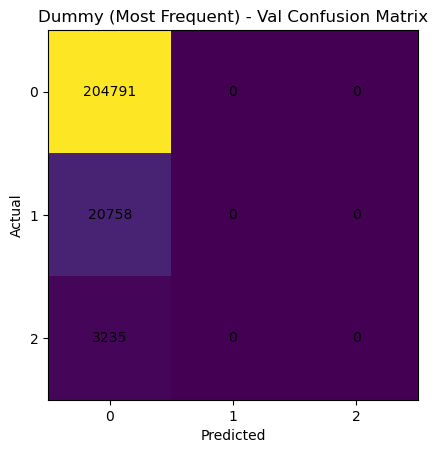

In [14]:
# --- Baseline 1: Dummy (most frequent) ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_val = dummy.predict(X_val)
eval_multiclass(y_val, pred_val, name="Dummy (Most Frequent) - Val")
def apply_two_thresholds(proba, tau1, tau2):
    """
    Decision rule:
      if P2 >= tau2 -> 2
      elif P1 >= tau1 -> 1
      else -> 0
    """
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # overwrite -> class 2 wins
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== LogReg Argmax - Val ===
Per-class recall [0,1,2]: [0.6539 0.3483 0.6019]
Macro recall: 0.5347
High-risk recall: 0.6019
High-risk precision: 0.0596

               precision    recall  f1-score   support

           0     0.9519    0.6539    0.7752    204791
           1     0.1304    0.3483    0.1898     20758
           2     0.0596    0.6019    0.1085      3235

    accuracy                         0.6254    228784
   macro avg     0.3806    0.5347    0.3578    228784
weighted avg     0.8647    0.6254    0.7127    228784



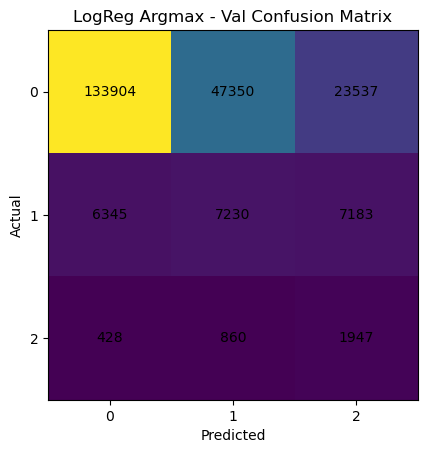


=== LogReg Argmax - Test ===
Per-class recall [0,1,2]: [0.6357 0.3313 0.6743]
Macro recall: 0.5471
High-risk recall: 0.6743
High-risk precision: 0.0608

               precision    recall  f1-score   support

           0     0.9543    0.6357    0.7631    207818
           1     0.1250    0.3313    0.1815     21189
           2     0.0608    0.6743    0.1116      3411

    accuracy                         0.6085    232418
   macro avg     0.3800    0.5471    0.3521    232418
weighted avg     0.8656    0.6085    0.7005    232418



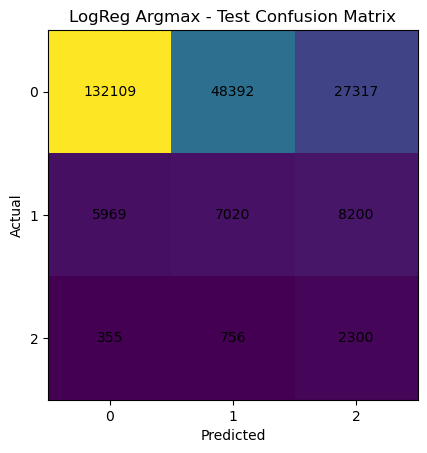

In [15]:
# --- Baseline 2: Logistic Regression (convergence fix) ---
logreg = LogisticRegression(
    solver="saga",
    max_iter=2000,   # fix convergence
    tol=1e-3,
    n_jobs=-1,
    class_weight="balanced"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

logreg_pipe.fit(X_train, y_train)

pred_val = logreg_pipe.predict(X_val)
eval_multiclass(y_val, pred_val, name="LogReg Argmax - Val")

pred_test = logreg_pipe.predict(X_test)
eval_multiclass(y_test, pred_test, name="LogReg Argmax - Test")
def apply_two_thresholds(proba, tau1, tau2):
    """
    Decision rule:
      if P2 >= tau2 -> 2
      elif P1 >= tau1 -> 1
      else -> 0
    """
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # overwrite -> class 2 wins
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df

Chosen thresholds: {'tau1': 0.35, 'tau2': 0.4}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
72,0.40,0.350,0.530274,0.232681,0.682535,0.051793,0.186337
71,0.40,0.325,0.529844,0.205270,0.718393,0.047642,0.213214
59,0.35,0.400,0.529243,0.458040,0.605873,0.061481,0.139345
73,0.40,0.375,0.528873,0.259177,0.642349,0.056261,0.161440
58,0.35,0.375,0.528139,0.419790,0.642349,0.056261,0.161440
74,0.40,0.400,0.527925,0.283891,0.605873,0.061481,0.139345
57,0.35,0.350,0.527908,0.380624,0.682535,0.051793,0.186337
56,0.35,0.325,0.526076,0.341411,0.718393,0.047642,0.213214
70,0.40,0.300,0.525866,0.174535,0.748377,0.043396,0.243850
69,0.40,0.275,0.521841,0.143945,0.779598,0.039715,0.277567



=== LogReg Two-Threshold (tau1=0.35, tau2=0.40) - Test ===
Per-class recall [0,1,2]: [0.5116 0.4376 0.6749]
Macro recall: 0.5414
High-risk recall: 0.6749
High-risk precision: 0.0628

               precision    recall  f1-score   support

           0     0.9641    0.5116    0.6685    207818
           1     0.1084    0.4376    0.1738     21189
           2     0.0628    0.6749    0.1150      3411

    accuracy                         0.5072    232418
   macro avg     0.3785    0.5414    0.3191    232418
weighted avg     0.8729    0.5072    0.6152    232418



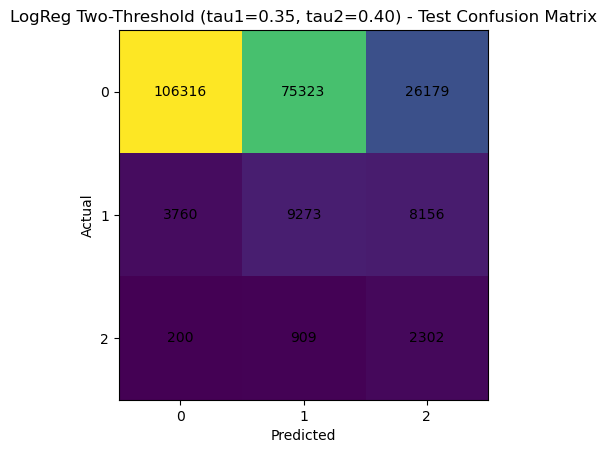

In [16]:
# --- Two-threshold tuning (Val) and apply on Test ---
proba_val = logreg_pipe.predict_proba(X_val)
tau1, tau2, grid = tune_two_thresholds(proba_val, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
print("Chosen thresholds:", {"tau1": tau1, "tau2": tau2})
display(grid.sort_values(["macro_recall","recall_2","precision_2"], ascending=False).head(10))

pred_test_thr = apply_two_thresholds(logreg_pipe.predict_proba(X_test), tau1, tau2)
eval_multiclass(y_test, pred_test_thr, name=f"LogReg Two-Threshold (tau1={tau1:.2f}, tau2={tau2:.2f}) - Test")